# FIT5149 Assessment 1: Sanctioned Loan Amount Prediction

This notebook starts the assessment from a clean implementation. It establishes the condition of the supplied data, records reproducible evidence for cleaning decisions, constructs lending-related features, and compares three regression model families with the same cross-validation folds.

This is a **model-development notebook**, not yet the final packaged implementation. The Kaggle submission is deliberately postponed until the final model has been selected using internal validation.

## Workflow

1. Load and validate the supplied files.
2. Investigate missing values, sentinel codes, impossible values, redundancy, and the target structure.
3. Define deterministic feature engineering.
4. Compare Ridge, Random Forest, and Histogram Gradient Boosting regression.
5. Diagnose out-of-fold errors and decide the next experiments.

In [1]:
from pathlib import Path
import os
import platform
import sys
import time
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "sanctioned_amount_aud"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

np.random.seed(RANDOM_STATE)

## 1. Load the supplied data

The notebook uses paths relative to its own folder. This avoids machine-specific absolute paths and makes the final implementation easier to reproduce.

In [2]:
DATA_DIR = Path.cwd()
if not (DATA_DIR / "training_set.csv").exists():
    candidate = Path.cwd() / "Assignment" / "A1"
    if (candidate / "training_set.csv").exists():
        DATA_DIR = candidate

train = pd.read_csv(DATA_DIR / "training_set.csv")
test = pd.read_csv(DATA_DIR / "kaggle_test_X.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Training data: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Kaggle test:  {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"Submission:   {sample_submission.shape[0]:,} rows x {sample_submission.shape[1]} columns")

Training data: 19,322 rows x 29 columns
Kaggle test:  10,000 rows x 28 columns
Submission:   10,000 rows x 2 columns


## 2. File and schema integrity checks

These checks fail early if a supplied file is missing, the row order no longer matches the submission template, or identifiers are duplicated. `application_id` is retained for the final output but excluded from predictors, as required by the data dictionary.

In [3]:
expected_train_shape = (19_322, 29)
expected_test_shape = (10_000, 28)

assert train.shape == expected_train_shape
assert test.shape == expected_test_shape
assert TARGET in train.columns and TARGET not in test.columns
assert train.drop(columns=TARGET).columns.tolist() == test.columns.tolist()
assert train["application_id"].is_unique
assert test["application_id"].is_unique
assert test["application_id"].equals(sample_submission["application_id"])
assert sample_submission.columns.tolist() == ["application_id", TARGET]
assert train["application_id"].str.fullmatch(r"LN-\d{6}").all()
assert test["application_id"].str.fullmatch(r"LN-\d{6}").all()

train_dates = pd.to_datetime(train["application_date"], format="%d/%m/%Y", errors="raise")
test_dates = pd.to_datetime(test["application_date"], format="%d/%m/%Y", errors="raise")

integrity_checks = pd.Series(
    {
        "training_rows": len(train),
        "test_rows": len(test),
        "duplicate_training_rows": int(train.duplicated().sum()),
        "duplicate_test_rows": int(test.duplicated().sum()),
        "duplicate_training_ids": int(train["application_id"].duplicated().sum()),
        "duplicate_test_ids": int(test["application_id"].duplicated().sum()),
        "shared_ids_between_train_and_test": int(
            train["application_id"].isin(test["application_id"]).sum()
        ),
        "training_date_min": train_dates.min().date(),
        "training_date_max": train_dates.max().date(),
        "test_date_min": test_dates.min().date(),
        "test_date_max": test_dates.max().date(),
    }
)

print("All schema and identifier checks passed.")
integrity_checks

All schema and identifier checks passed.


training_rows                             19322
test_rows                                 10000
duplicate_training_rows                       0
duplicate_test_rows                           0
duplicate_training_ids                        0
duplicate_test_ids                            0
shared_ids_between_train_and_test             0
training_date_min                    2023-01-01
training_date_max                    2024-12-30
test_date_min                        2023-01-01
test_date_max                        2024-12-30
dtype: object

## 3. Data quality investigation

The marking guide rewards evidence about the actual dataset rather than a generic checklist. The following audit measures missingness, cardinality, and coded sentinel values for every variable.

In [4]:
quality_audit = pd.DataFrame(
    {
        "dtype": train.dtypes.astype(str),
        "missing_n": train.isna().sum(),
        "missing_pct": 100 * train.isna().mean(),
        "unique_including_missing": train.nunique(dropna=False),
    }
)

numeric_columns_raw = train.select_dtypes(include="number").columns
quality_audit["sentinel_minus_999_n"] = [
    int((train[column] == -999).sum()) if column in numeric_columns_raw else 0
    for column in quality_audit.index
]

quality_audit.sort_values(
    ["missing_pct", "sentinel_minus_999_n"], ascending=False
).style.format({"missing_pct": "{:.2f}%"})

,dtype,missing_n,missing_pct,unique_including_missing,sentinel_minus_999_n
property_age_years,float64,6260,32.40%,12773,0
monthly_income_aud,float64,4963,25.69%,12331,0
annual_income_aud,float64,4848,25.09%,14151,0
employment_sector,object,4706,24.36%,19,0
credit_rating,float64,3953,20.46%,11646,0
existing_repayments_aud,float64,2294,11.87%,14910,100
dependants_count,float64,1576,8.16%,10,0
property_value_aud,float64,1178,6.10%,17943,199
income_consistency,object,1077,5.57%,3,0
property_area,object,219,1.13%,4,0


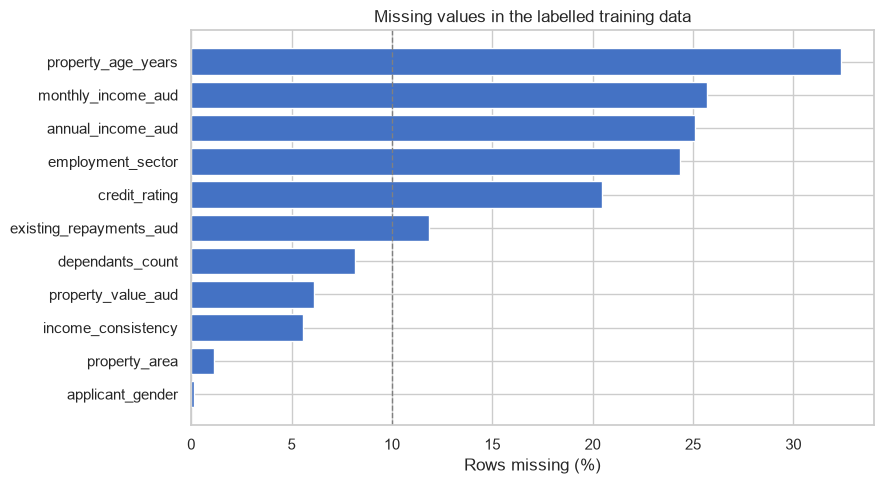

In [5]:
missing_plot = quality_audit.query("missing_n > 0").sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(missing_plot.index, missing_plot["missing_pct"], color="#4472C4")
ax.set(title="Missing values in the labelled training data", xlabel="Rows missing (%)", ylabel="")
ax.axvline(10, color="grey", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

### 3.1 Missingness differs by variable and may carry signal

Missingness is compared between training and test before any imputation. The target comparison below is descriptive rather than causal: a large difference shows that the absence of a field may be predictive and should not automatically be erased by simple imputation. Specific missingness indicators and an aggregate missing-value count are therefore evaluated in the feature-engineering ablation.

In [6]:
train_missing_pct = 100 * train.isna().mean()
test_missing_pct = 100 * test.isna().mean().reindex(train.columns).fillna(0)

missingness_comparison = pd.DataFrame(
    {
        "train_missing_n": train.isna().sum(),
        "train_missing_pct": train_missing_pct,
        "test_missing_n": test.isna().sum().reindex(train.columns).fillna(0).astype(int),
        "test_missing_pct": test_missing_pct,
        "test_minus_train_pct_points": test_missing_pct - train_missing_pct,
    }
).query("train_missing_n > 0 or test_missing_n > 0")

missingness_comparison.sort_values("train_missing_pct", ascending=False).style.format(
    {
        "train_missing_pct": "{:.2f}%",
        "test_missing_pct": "{:.2f}%",
        "test_minus_train_pct_points": "{:+.2f}",
    }
)

,train_missing_n,train_missing_pct,test_missing_n,test_missing_pct,test_minus_train_pct_points
property_age_years,6260,32.40%,3262,32.62%,+0.22
monthly_income_aud,4963,25.69%,2484,24.84%,-0.85
annual_income_aud,4848,25.09%,2485,24.85%,-0.24
employment_sector,4706,24.36%,2419,24.19%,-0.17
credit_rating,3953,20.46%,2133,21.33%,+0.87
existing_repayments_aud,2294,11.87%,1186,11.86%,-0.01
dependants_count,1576,8.16%,826,8.26%,+0.10
property_value_aud,1178,6.10%,581,5.81%,-0.29
income_consistency,1077,5.57%,551,5.51%,-0.06
property_area,219,1.13%,122,1.22%,+0.09


In [7]:
train_missing_work = train.copy()
for column in ["existing_repayments_aud", "has_co_applicant", "property_value_aud"]:
    train_missing_work[column] = train_missing_work[column].replace(-999, np.nan)

# Include true NaN fields here. Sentinel fields are added after their definition below.
missing_target_rows = []
for column in train.columns.drop(TARGET):
    missing_mask = train_missing_work[column].isna()
    if missing_mask.any() and (~missing_mask).any():
        missing_target_rows.append(
            {
                "feature": column,
                "missing_n": int(missing_mask.sum()),
                "missing_pct": 100 * missing_mask.mean(),
                "mean_target_when_missing": train.loc[missing_mask, TARGET].mean(),
                "mean_target_when_present": train.loc[~missing_mask, TARGET].mean(),
                "target_mean_difference": (
                    train.loc[missing_mask, TARGET].mean()
                    - train.loc[~missing_mask, TARGET].mean()
                ),
                "zero_sanction_when_missing_pct": 100 * (train.loc[missing_mask, TARGET] == 0).mean(),
                "zero_sanction_when_present_pct": 100 * (train.loc[~missing_mask, TARGET] == 0).mean(),
            }
        )

missing_target_evidence = (
    pd.DataFrame(missing_target_rows)
    .assign(abs_target_difference=lambda frame: frame["target_mean_difference"].abs())
    .sort_values("abs_target_difference", ascending=False)
    .drop(columns="abs_target_difference")
)

missing_target_evidence.style.format(
    {
        "missing_pct": "{:.2f}%",
        "mean_target_when_missing": "${:,.0f}",
        "mean_target_when_present": "${:,.0f}",
        "target_mean_difference": "${:+,.0f}",
        "zero_sanction_when_missing_pct": "{:.1f}%",
        "zero_sanction_when_present_pct": "{:.1f}%",
    }
)

,feature,missing_n,missing_pct,mean_target_when_missing,mean_target_when_present,target_mean_difference,zero_sanction_when_missing_pct,zero_sanction_when_present_pct
2,income_consistency,1077,5.57%,"$91,495","$73,868","$+17,627",10.7%,27.7%
4,existing_repayments_aud,2394,12.39%,"$90,259","$72,671","$+17,588",24.9%,27.1%
5,dependants_count,1576,8.16%,"$90,761","$73,437","$+17,323",12.8%,28.0%
8,property_area,219,1.13%,"$90,905","$74,666","$+16,238",9.1%,27.0%
11,monthly_income_aud,4963,25.69%,"$83,407","$71,893","$+11,515",19.4%,29.4%
9,has_co_applicant,107,0.55%,"$84,233","$74,798","$+9,435",21.5%,26.8%
1,annual_income_aud,4848,25.09%,"$81,747","$72,540","$+9,207",20.2%,29.0%
7,property_age_years,6260,32.40%,"$81,003","$71,902","$+9,101",21.0%,29.6%
3,employment_sector,4706,24.36%,"$79,716","$73,284","$+6,432",21.7%,28.4%
6,credit_rating,3953,20.46%,"$77,948","$74,054","$+3,894",22.5%,27.9%


#### Missingness patterns across observable groups

To investigate whether missingness is completely random, the largest within-group difference is calculated for several observable contexts. Large percentage-point spreads indicate that a single global imputation value is unlikely to capture the full pattern. These comparisons remain descriptive and do not prove a missing-data mechanism.

In [8]:
missing_context_work = train_missing_work.copy()
missing_context_work["application_year"] = train_dates.dt.year

missingness_features = [
    "property_age_years",
    "monthly_income_aud",
    "annual_income_aud",
    "employment_sector",
    "credit_rating",
    "existing_repayments_aud",
    "dependants_count",
    "property_value_aud",
]
context_features = [
    "marketing_channel",
    "occupation_class",
    "residence_area",
    "application_year",
]

missing_context_rows = []
for missing_feature in missingness_features:
    for context_feature in context_features:
        grouped_missingness = (
            missing_context_work.groupby(context_feature, dropna=False)[missing_feature]
            .agg(group_n="size", missing_rate=lambda values: values.isna().mean())
            .query("group_n >= 30")
        )
        rates = grouped_missingness["missing_rate"].sort_values()
        missing_context_rows.append(
            {
                "missing_feature": missing_feature,
                "grouped_by": context_feature,
                "lowest_missing_group": str(rates.index[0]),
                "lowest_missing_pct": 100 * rates.iloc[0],
                "highest_missing_group": str(rates.index[-1]),
                "highest_missing_pct": 100 * rates.iloc[-1],
                "spread_percentage_points": 100 * (rates.iloc[-1] - rates.iloc[0]),
            }
        )

missingness_by_context = (
    pd.DataFrame(missing_context_rows)
    .sort_values("spread_percentage_points", ascending=False)
    .reset_index(drop=True)
)

missingness_by_context.head(15).style.format(
    {
        "lowest_missing_pct": "{:.1f}%",
        "highest_missing_pct": "{:.1f}%",
        "spread_percentage_points": "{:.1f}",
    }
)

,missing_feature,grouped_by,lowest_missing_group,lowest_missing_pct,highest_missing_group,highest_missing_pct,spread_percentage_points
0,employment_sector,occupation_class,salaried,15.8%,retiree,100.0%,84.2
1,credit_rating,occupation_class,public_sector,11.1%,retiree,46.5%,35.4
2,credit_rating,residence_area,inner_metro,18.7%,regional,25.2%,6.5
3,property_age_years,occupation_class,public_sector,30.7%,retiree,35.5%,4.8
4,monthly_income_aud,occupation_class,public_sector,22.0%,retiree,26.6%,4.6
5,annual_income_aud,occupation_class,public_sector,21.2%,salaried,25.5%,4.3
6,monthly_income_aud,marketing_channel,referral,23.5%,branch_walkin,26.8%,3.3
7,employment_sector,residence_area,outer_metro,24.1%,inner_metro,26.5%,2.5
8,monthly_income_aud,residence_area,outer_metro,25.3%,inner_metro,27.4%,2.2
9,annual_income_aud,residence_area,regional,24.8%,inner_metro,26.9%,2.1


In [9]:
categorical_columns_raw = [
    column
    for column in train.select_dtypes(include=["object"]).columns
    if column not in ["application_id", "application_date"]
]

category_summary = []
for column in categorical_columns_raw:
    train_levels = set(train[column].dropna().unique())
    test_levels = set(test[column].dropna().unique())
    category_summary.append(
        {
            "feature": column,
            "train_levels": len(train_levels),
            "test_levels": len(test_levels),
            "train_only_levels": sorted(train_levels - test_levels),
            "test_only_levels": sorted(test_levels - train_levels),
            "rarest_train_level_n": int(train[column].value_counts().min()),
        }
    )

pd.DataFrame(category_summary)

,feature,train_levels,test_levels,train_only_levels,test_only_levels,rarest_train_level_n
0,applicant_gender,2,2,[],[],9608
1,income_consistency,2,2,[],[],1674
2,occupation_class,8,4,"[no_employment, parental_leave, proprietor, st...",[],1
3,employment_sector,18,18,[],[],47
4,residence_area,3,3,[],[],1994
5,expense_flag_a,2,2,[],[],6935
6,expense_flag_b,2,2,[],[],6370
7,card_status,4,4,[],[],980
8,property_category,4,4,[],[],4630
9,property_area,3,3,[],[],5996


### 3.2 Sentinel codes are missing values, not measurements

The value `-999` appears in variables that cannot meaningfully be negative. It is converted to missing before modelling. Imputation remains inside each model pipeline so that validation folds cannot influence their training folds.

In [10]:
SENTINEL_COLUMNS = [
    "existing_repayments_aud",
    "has_co_applicant",
    "property_value_aud",
]

sentinel_counts = pd.DataFrame(
    {
        "training_minus_999": [(train[column] == -999).sum() for column in SENTINEL_COLUMNS],
        "training_pct": [100 * (train[column] == -999).mean() for column in SENTINEL_COLUMNS],
        "test_minus_999": [(test[column] == -999).sum() for column in SENTINEL_COLUMNS],
        "test_pct": [100 * (test[column] == -999).mean() for column in SENTINEL_COLUMNS],
    },
    index=SENTINEL_COLUMNS,
)
sentinel_counts.style.format({"training_pct": "{:.2f}%", "test_pct": "{:.2f}%"})

,training_minus_999,training_pct,test_minus_999,test_pct
existing_repayments_aud,100,0.52%,50,0.50%
has_co_applicant,107,0.55%,53,0.53%
property_value_aud,199,1.03%,110,1.10%


### 3.3 `property_age_years` is not a plausible property age

This is the most important data-quality finding. Every row with both `property_age_years` and `annual_income_aud` present contains exactly the same value in the two columns, and no recorded property age is 200 years or less. The field is therefore treated as a corrupted duplicate of annual income, not as property age.

The field is dropped from the model. The ablation study later in the notebook also tests whether using it only as an income backup adds measurable predictive value; the tested backup does not improve validation RMSE.

In [11]:
income_property_overlap = train[["annual_income_aud", "property_age_years"]].dropna()
exact_matches = np.isclose(
    income_property_overlap["annual_income_aud"],
    income_property_overlap["property_age_years"],
    rtol=0,
    atol=0.001,
)

income_month_overlap = train[["annual_income_aud", "monthly_income_aud"]].dropna()
annual_to_monthly_ratio = (
    income_month_overlap["annual_income_aud"]
    / income_month_overlap["monthly_income_aud"]
)

data_quality_evidence = pd.Series(
    {
        "rows where annual income and property age both exist": len(income_property_overlap),
        "exact matches between those two fields": int(exact_matches.sum()),
        "plausible property ages between 0 and 200": int(train["property_age_years"].between(0, 200).sum()),
        "correlation of annual and monthly income": income_month_overlap.corr().iloc[0, 1],
        "median annual/monthly income ratio": annual_to_monthly_ratio.median(),
    }
)
data_quality_evidence

rows where annual income and property age both exist   11,524.000
exact matches between those two fields                 11,524.000
plausible property ages between 0 and 200                   0.000
correlation of annual and monthly income                    1.000
median annual/monthly income ratio                         11.999
dtype: float64

### 3.4 Business-rule checks, extreme values, and dataset shift

The following checks distinguish demonstrably invalid observations from merely extreme observations. Extreme but possible values are retained for modelling; hard corrections are limited to the documented `-999` sentinels and the corrupted property-age field.

Train/test shift is summarised using standardised mean differences for numeric fields and total-variation distance for categorical fields. These measures are descriptive screening tools, not hypothesis tests.

In [12]:
train_clean_for_audit = train.copy()
test_clean_for_audit = test.copy()
for column in SENTINEL_COLUMNS:
    train_clean_for_audit[column] = train_clean_for_audit[column].replace(-999, np.nan)
    test_clean_for_audit[column] = test_clean_for_audit[column].replace(-999, np.nan)

business_rule_checks = pd.Series(
    {
        "requested_amount_nonpositive": int((train["requested_amount_aud"] <= 0).sum()),
        "sanctioned_amount_negative": int((train[TARGET] < 0).sum()),
        "sanctioned_above_requested": int((train[TARGET] > train["requested_amount_aud"]).sum()),
        "applicant_age_below_18": int((train["applicant_age"] < 18).sum()),
        "applicant_age_above_100": int((train["applicant_age"] > 100).sum()),
        "annual_income_nonpositive": int((train["annual_income_aud"] <= 0).sum()),
        "monthly_income_nonpositive": int((train["monthly_income_aud"] <= 0).sum()),
        "property_value_nonpositive_after_sentinel_cleaning": int(
            (train_clean_for_audit["property_value_aud"] <= 0).sum()
        ),
        "repayments_negative_after_sentinel_cleaning": int(
            (train_clean_for_audit["existing_repayments_aud"] < 0).sum()
        ),
    }
)

numeric_summary = (
    train_clean_for_audit.select_dtypes(include="number")
    .drop(columns=TARGET)
    .quantile([0, 0.01, 0.5, 0.99, 1])
    .T
    .rename(columns={0.0: "min", 0.01: "p01", 0.5: "median", 0.99: "p99", 1.0: "max"})
)

display(business_rule_checks)
display(numeric_summary.style.format("{:,.2f}"))

requested_amount_nonpositive                          0
sanctioned_amount_negative                            0
sanctioned_above_requested                            0
applicant_age_below_18                                0
applicant_age_above_100                               0
annual_income_nonpositive                             0
monthly_income_nonpositive                            0
property_value_nonpositive_after_sentinel_cleaning    0
repayments_negative_after_sentinel_cleaning           0
dtype: int64

,min,p01,median,p99,max
applicant_age,18.00,18.00,40.00,65.00,65.00
annual_income_aud,585.43,"1,165.84","3,411.84","11,810.78","2,755,063.33"
requested_amount_aud,"9,467.48","18,167.70","116,439.51","429,442.27","933,695.43"
existing_repayments_aud,52.76,140.44,566.30,"1,617.95","5,953.36"
dependants_count,1.00,1.00,2.00,5.00,10.00
credit_rating,580.85,600.55,737.23,872.77,891.95
prior_default_count,0.00,0.00,0.00,1.00,1.00
property_ref,1.00,11.00,502.00,989.79,999.00
property_age_years,585.43,"1,156.66","3,401.61","11,815.13","2,755,063.33"
has_co_applicant,0.00,0.00,1.00,1.00,1.00


In [13]:
common_numeric = [
    column
    for column in train_clean_for_audit.select_dtypes(include="number").columns
    if column in test_clean_for_audit.columns and column not in ["property_age_years"]
]

numeric_shift_rows = []
for column in common_numeric:
    train_values = train_clean_for_audit[column].dropna()
    test_values = test_clean_for_audit[column].dropna()
    pooled_sd = np.sqrt((train_values.var() + test_values.var()) / 2)
    smd = (test_values.mean() - train_values.mean()) / pooled_sd if pooled_sd > 0 else 0
    numeric_shift_rows.append(
        {
            "feature": column,
            "train_mean": train_values.mean(),
            "test_mean": test_values.mean(),
            "standardised_mean_difference": smd,
        }
    )

categorical_shift_rows = []
for column in categorical_columns_raw:
    train_share = train[column].fillna("<MISSING>").value_counts(normalize=True)
    test_share = test[column].fillna("<MISSING>").value_counts(normalize=True)
    all_levels = train_share.index.union(test_share.index)
    total_variation = 0.5 * (
        train_share.reindex(all_levels, fill_value=0)
        - test_share.reindex(all_levels, fill_value=0)
    ).abs().sum()
    categorical_shift_rows.append(
        {"feature": column, "total_variation_distance": total_variation}
    )

numeric_shift = pd.DataFrame(numeric_shift_rows).sort_values(
    "standardised_mean_difference", key=lambda values: values.abs(), ascending=False
)
categorical_shift = pd.DataFrame(categorical_shift_rows).sort_values(
    "total_variation_distance", ascending=False
)

display(numeric_shift.style.format({
    "train_mean": "{:,.2f}",
    "test_mean": "{:,.2f}",
    "standardised_mean_difference": "{:+.3f}",
}))
display(categorical_shift.style.format({"total_variation_distance": "{:.3f}"}))

,feature,train_mean,test_mean,standardised_mean_difference
0,applicant_age,40.24,39.89,-0.022
4,dependants_count,2.25,2.26,+0.013
3,existing_repayments_aud,616.61,620.41,+0.011
5,credit_rating,737.79,736.97,-0.011
7,property_ref,500.92,504.12,+0.011
12,enquiry_count_12m,3.73,3.70,-0.011
1,annual_income_aud,"4,165.23","3,994.20",-0.010
10,monthly_income_aud,346.76,332.00,-0.010
9,property_value_aud,"205,915.64","207,315.24",+0.010
2,requested_amount_aud,"137,378.44","138,053.65",+0.007


,feature,total_variation_distance
11,branch_id,0.061
3,employment_sector,0.015
8,property_category,0.012
7,card_status,0.011
9,property_area,0.009
4,residence_area,0.008
10,marketing_channel,0.006
6,expense_flag_b,0.006
2,occupation_class,0.005
0,applicant_gender,0.003


### 3.5 Univariate relationships with the target

Pearson correlation measures linear association, while Spearman correlation also captures monotonic nonlinear relationships. The categorical summary reports the spread in mean sanctioned amount across adequately represented levels. These are screening statistics only: they do not control for requested loan size or establish causal influence.

In [14]:
numeric_for_relationships = train_clean_for_audit.select_dtypes(include="number").drop(
    columns=["property_age_years"]
)
numeric_target_relationships = pd.DataFrame(
    {
        "pearson_with_target": numeric_for_relationships.corr(method="pearson")[TARGET],
        "spearman_with_target": numeric_for_relationships.corr(method="spearman")[TARGET],
    }
).drop(index=TARGET)
numeric_target_relationships["max_absolute_relationship"] = numeric_target_relationships.abs().max(axis=1)
numeric_target_relationships = numeric_target_relationships.sort_values(
    "max_absolute_relationship", ascending=False
)

categorical_target_rows = []
for column in categorical_columns_raw:
    grouped = (
        train.assign(_category=train[column].fillna("<MISSING>"))
        .groupby("_category", dropna=False)[TARGET]
        .agg(["size", "mean"])
        .query("size >= 30")
    )
    categorical_target_rows.append(
        {
            "feature": column,
            "eligible_levels": len(grouped),
            "minimum_level_mean_target": grouped["mean"].min(),
            "maximum_level_mean_target": grouped["mean"].max(),
            "mean_target_spread": grouped["mean"].max() - grouped["mean"].min(),
        }
    )

categorical_target_relationships = pd.DataFrame(categorical_target_rows).sort_values(
    "mean_target_spread", ascending=False
)

display(numeric_target_relationships.style.format("{:+.3f}"))
display(categorical_target_relationships.style.format({
    "minimum_level_mean_target": "${:,.0f}",
    "maximum_level_mean_target": "${:,.0f}",
    "mean_target_spread": "${:,.0f}",
}))

,pearson_with_target,spearman_with_target,max_absolute_relationship
requested_amount_aud,+0.740,+0.601,+0.740
property_value_aud,+0.712,+0.582,+0.712
existing_repayments_aud,+0.563,+0.481,+0.563
credit_rating,+0.375,+0.404,+0.404
has_co_applicant,+0.269,+0.350,+0.350
annual_income_aud,+0.030,+0.225,+0.225
monthly_income_aud,+0.029,+0.220,+0.220
risk_review_flag,-0.114,-0.127,+0.127
property_ref,-0.016,-0.017,+0.017
applicant_age,+0.006,+0.016,+0.016


,feature,eligible_levels,minimum_level_mean_target,maximum_level_mean_target,mean_target_spread
11,branch_id,200,"$50,044","$128,894","$78,850"
3,employment_sector,19,"$43,807","$105,106","$61,298"
4,residence_area,3,"$68,024","$102,847","$34,823"
7,card_status,4,"$73,494","$92,705","$19,211"
1,income_consistency,3,"$72,910","$91,495","$18,585"
2,occupation_class,4,"$68,254","$85,434","$17,180"
9,property_area,4,"$74,217","$90,905","$16,687"
5,expense_flag_a,2,"$71,154","$81,453","$10,299"
10,marketing_channel,5,"$71,959","$76,820","$4,861"
0,applicant_gender,2,"$74,207","$75,496","$1,288"


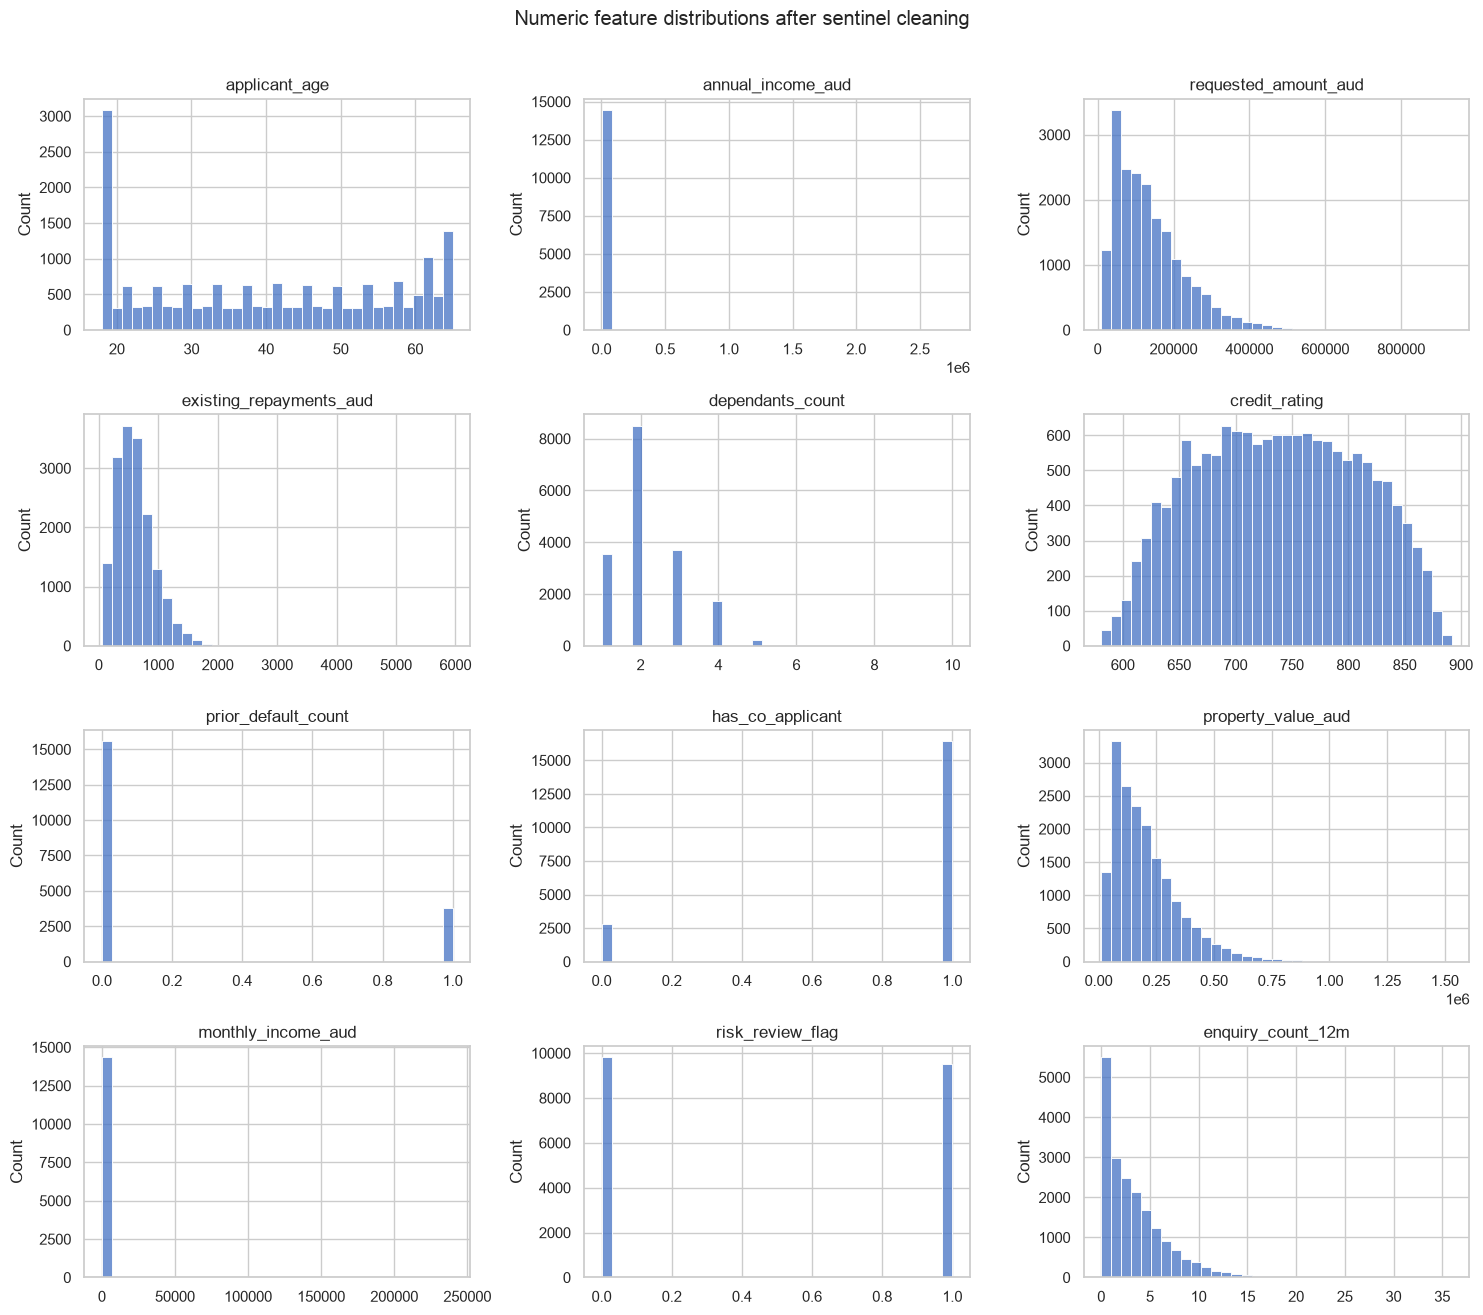

In [15]:
distribution_columns = [
    column
    for column in numeric_for_relationships.columns
    if column not in [TARGET, "property_ref"]
]

fig, axes = plt.subplots(4, 3, figsize=(15, 13))
for column, ax in zip(distribution_columns, axes.flat):
    values = train_clean_for_audit[column].dropna()
    sns.histplot(values, bins=35, ax=ax, color="#4472C4")
    ax.set_title(column)
    ax.set_xlabel("")

for ax in axes.flat[len(distribution_columns):]:
    ax.set_visible(False)

fig.suptitle("Numeric feature distributions after sentinel cleaning", y=1.01)
plt.tight_layout()
plt.show()

## 4. Target investigation

RMSE is sensitive to large errors, so the scale and structure of the target matter. Here, 26.8% of labelled applications have zero sanctioned amount. For every row, the sanctioned amount is no greater than the requested amount.

More unusually, the sanctioned amount is almost exactly a fixed proportion of the requested amount. The observed proportions are 0%, 65%, 70%, 75%, 80%, 85%, 90%, and 100%. This suggests a tiered underwriting decision. It motivates stratifying validation folds by sanction tier and testing a rate-based model later, while the initial comparison below remains a direct regression on AUD.

In [16]:
y = train[TARGET].copy()
requested = train["requested_amount_aud"]
sanction_rate = (y / requested).round(2)

target_checks = pd.Series(
    {
        "zero_target_n": int((y == 0).sum()),
        "zero_target_pct": 100 * (y == 0).mean(),
        "sanction_above_request_n": int((y > requested).sum()),
        "unique_rounded_sanction_rates": sorted(sanction_rate.unique().tolist()),
    }
)
target_checks

zero_target_n                                                           5177
zero_target_pct                                                       26.793
sanction_above_request_n                                                   0
unique_rounded_sanction_rates    [0.0, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
dtype: object

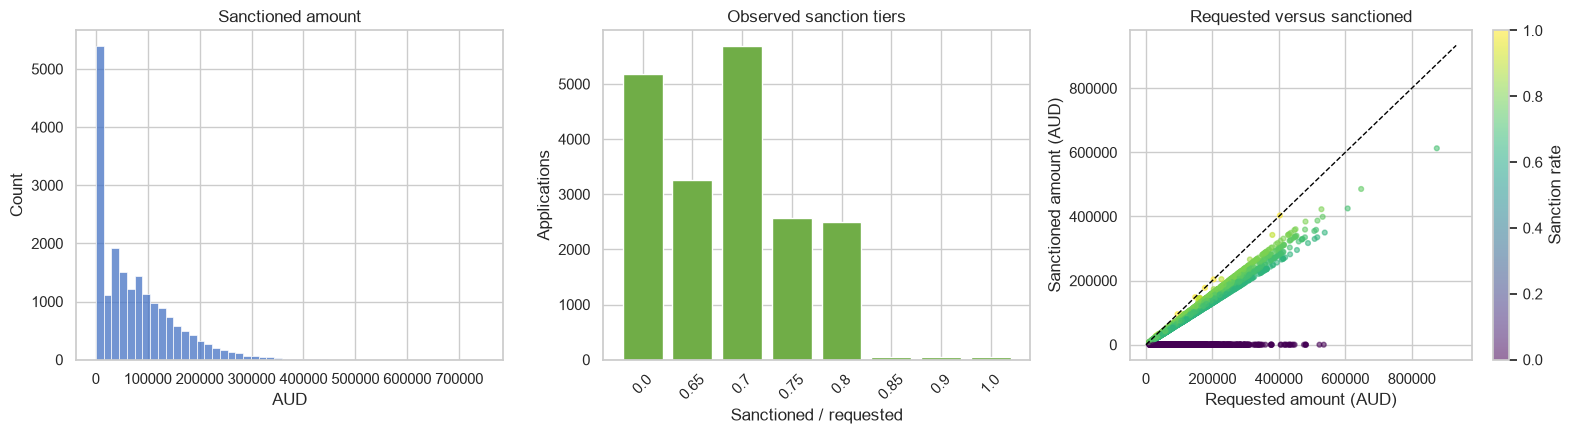

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(y, bins=50, ax=axes[0], color="#4472C4")
axes[0].set(title="Sanctioned amount", xlabel="AUD")

rate_counts = sanction_rate.value_counts().sort_index()
axes[1].bar(rate_counts.index.astype(str), rate_counts.values, color="#70AD47")
axes[1].set(title="Observed sanction tiers", xlabel="Sanctioned / requested", ylabel="Applications")
axes[1].tick_params(axis="x", rotation=45)

sample_for_plot = train.sample(n=min(4_000, len(train)), random_state=RANDOM_STATE)
sample_rate = (sample_for_plot[TARGET] / sample_for_plot["requested_amount_aud"]).round(2)
scatter = axes[2].scatter(
    sample_for_plot["requested_amount_aud"],
    sample_for_plot[TARGET],
    c=sample_rate,
    cmap="viridis",
    s=12,
    alpha=0.55,
)
axes[2].plot([0, requested.max()], [0, requested.max()], color="black", linestyle="--", linewidth=1)
axes[2].set(title="Requested versus sanctioned", xlabel="Requested amount (AUD)", ylabel="Sanctioned amount (AUD)")
fig.colorbar(scatter, ax=axes[2], label="Sanction rate")

plt.tight_layout()
plt.show()

## 5. Deterministic cleaning and feature engineering

Only transformations that do not learn from other rows are performed before cross-validation. All learned steps, including imputation, scaling, and category encoding, remain inside the pipelines.

The constructed features reflect lending decisions:

- requested amount relative to property value;
- requested amount relative to reconciled annual income;
- existing repayments relative to reconciled monthly income;
- property value remaining after the requested loan;
- cyclical calendar position and application year;
- specific missingness indicators and an aggregate missing-value count.

The function has explicit switches so that the value of these choices can be measured with the same folds in the ablation study rather than asserted without evidence.

In [18]:
MISSING_INDICATOR_COLUMNS = [
    column
    for column in train.drop(columns=TARGET).columns
    if train[column].isna().any() or column in SENTINEL_COLUMNS
]


def engineer_features(
    frame,
    *,
    use_income_backup=False,
    add_business_features=True,
    add_missing_indicators=True,
):
    x = frame.copy()

    for column in SENTINEL_COLUMNS:
        x[column] = x[column].replace(-999, np.nan)

    x["missing_value_count"] = x.isna().sum(axis=1)
    if add_missing_indicators:
        for column in MISSING_INDICATOR_COLUMNS:
            x[f"{column}_is_missing"] = x[column].isna().astype("int8")

    application_date = pd.to_datetime(
        x.pop("application_date"), format="%d/%m/%Y", errors="raise"
    )
    x["application_year"] = application_date.dt.year
    x["application_month_sin"] = np.sin(2 * np.pi * application_date.dt.month / 12)
    x["application_month_cos"] = np.cos(2 * np.pi * application_date.dt.month / 12)
    x["application_dayofyear_sin"] = np.sin(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )
    x["application_dayofyear_cos"] = np.cos(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )

    if add_business_features:
        income_candidates = [x["annual_income_aud"], 12 * x["monthly_income_aud"]]
        if use_income_backup:
            income_candidates.append(x["property_age_years"])
        income_candidates = pd.concat(income_candidates, axis=1)

        x["annual_income_reconciled_aud"] = income_candidates.median(axis=1, skipna=True)
        x["income_sources_available"] = income_candidates.notna().sum(axis=1)
        x["income_relative_gap"] = (
            (x["annual_income_aud"] - 12 * x["monthly_income_aud"]).abs()
            / x["annual_income_reconciled_aud"].replace(0, np.nan)
        )
        x["requested_to_property_value"] = (
            x["requested_amount_aud"] / x["property_value_aud"].replace(0, np.nan)
        )
        x["requested_to_annual_income"] = (
            x["requested_amount_aud"]
            / x["annual_income_reconciled_aud"].replace(0, np.nan)
        )
        x["repayments_to_monthly_income"] = (
            x["existing_repayments_aud"]
            / (x["annual_income_reconciled_aud"] / 12).replace(0, np.nan)
        )
        x["property_value_minus_requested"] = (
            x["property_value_aud"] - x["requested_amount_aud"]
        )

    x = x.drop(columns=["application_id", "property_age_years"])

    # Treat the repeated internal reference as a category, not a continuous number.
    x["property_ref"] = x["property_ref"].astype("string")
    return x


X = engineer_features(train.drop(columns=TARGET))
X_kaggle = engineer_features(test)

assert X.columns.tolist() == X_kaggle.columns.tolist()
assert not np.isinf(X.select_dtypes(include="number").to_numpy()).any()

print(f"Model matrix before learned preprocessing: {X.shape}")
print(f"Reconciled income remains missing for {X['annual_income_reconciled_aud'].isna().sum():,} rows")
X.head()

Model matrix before learned preprocessing: (19322, 50)
Reconciled income remains missing for 4,201 rows


,applicant_gender,applicant_age,annual_income_aud,income_consistency,occupation_class,employment_sector,residence_area,requested_amount_aud,existing_repayments_aud,expense_flag_a,expense_flag_b,dependants_count,credit_rating,prior_default_count,card_status,property_ref,property_category,property_area,has_co_applicant,property_value_aud,marketing_channel,branch_id,monthly_income_aud,risk_review_flag,enquiry_count_12m,missing_value_count,applicant_gender_is_missing,annual_income_aud_is_missing,income_consistency_is_missing,employment_sector_is_missing,existing_repayments_aud_is_missing,dependants_count_is_missing,credit_rating_is_missing,property_age_years_is_missing,property_area_is_missing,has_co_applicant_is_missing,property_value_aud_is_missing,monthly_income_aud_is_missing,application_year,application_month_sin,application_month_cos,application_dayofyear_sin,application_dayofyear_cos,annual_income_reconciled_aud,income_sources_available,income_relative_gap,requested_to_property_value,requested_to_annual_income,repayments_to_monthly_income,property_value_minus_requested
0,male,65,"3,572.420",steady,retiree,NaN,outer_metro,"80,823.310",369.810,no,yes,NaN,806.520,1,current,77,cat_c,NaN,1.000,"118,370.540",online,BR111,290.870,1,3,3,0,0,0,1,0,1,0,0,1,0,0,0,2024,-0.500,0.866,-0.497,0.868,"3,531.430",2,0.023,0.683,22.887,1.257,"37,547.230"
1,male,48,NaN,variable,salaried,retail,outer_metro,"41,673.080",188.250,no,no,2.000,613.700,1,current,743,cat_b,regional,0.000,"47,000.080",online,BR110,NaN,0,4,3,0,1,0,0,0,0,0,1,0,0,0,1,2023,-1.000,-0.000,-0.995,-0.102,NaN,0,NaN,0.887,NaN,NaN,"5,327.000"
2,female,18,"3,551.480",variable,salaried,retail,outer_metro,"199,076.750",941.270,no,yes,2.000,780.280,0,current,788,cat_b,outer_metro,1.000,"277,686.300",online,BR164,286.620,0,4,1,0,0,0,0,0,0,0,1,0,0,0,0,2024,-1.000,-0.000,-0.958,-0.287,"3,495.460",2,0.032,0.717,56.953,3.231,"78,609.550"
3,male,50,NaN,variable,commercial_partner,retail,inner_metro,"120,176.890",309.710,no,yes,2.000,NaN,0,none_held,709,cat_a,outer_metro,1.000,"203,173.220",online,BR051,NaN,1,3,4,0,1,0,0,0,0,1,1,0,0,0,1,2023,-0.500,-0.866,-0.391,-0.920,NaN,0,NaN,0.591,NaN,NaN,"82,996.330"
4,male,28,NaN,NaN,salaried,NaN,outer_metro,"62,745.530",454.490,no,no,NaN,NaN,0,current,772,cat_d,regional,1.000,"86,636.210",branch_walkin,BR072,NaN,1,2,7,0,1,1,1,0,1,1,1,0,0,0,1,2024,-0.000,1.000,-0.292,0.956,NaN,0,NaN,0.724,NaN,NaN,"23,890.680"


## 6. Validation design

The Kaggle public leaderboard uses only 2,000 rows and must not be used as a validation set. This notebook uses five shuffled folds with a fixed seed. Folds are stratified by the eight observed sanction tiers, which keeps the zero-sanction and rarer high-rate regimes represented in every fold.

The same precomputed folds are used for every model, enabling paired comparisons. Preprocessing is fitted separately inside each training fold, preventing leakage from imputation, scaling, or encoding.

In [19]:
strata = sanction_rate.map(lambda value: f"{value:.2f}")
splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds = list(splitter.split(X, strata))

fold_balance = []
for fold_number, (_, valid_index) in enumerate(folds, start=1):
    counts = strata.iloc[valid_index].value_counts(normalize=True).sort_index()
    fold_balance.append(counts.rename(f"fold_{fold_number}"))

pd.concat(fold_balance, axis=1).T.style.format("{:.2%}")

,0.00,0.65,0.70,0.75,0.80,0.85,0.90,1.00
fold_1,26.78%,16.84%,29.44%,13.30%,12.94%,0.23%,0.26%,0.21%
fold_2,26.80%,16.87%,29.42%,13.27%,12.94%,0.23%,0.26%,0.21%
fold_3,26.81%,16.87%,29.43%,13.28%,12.94%,0.21%,0.26%,0.21%
fold_4,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%
fold_5,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%


## 7. Preprocessing pipelines and candidate models

The model families are genuinely different:

1. **Ridge regression** is a regularised linear baseline. Numeric inputs are median-imputed and standardised; categorical inputs are imputed and one-hot encoded.
2. **Random Forest regression** captures interactions and nonlinear thresholds through bagged trees.
3. **Histogram Gradient Boosting regression** builds trees sequentially to correct earlier errors and treats encoded categorical columns as categorical features.

Rare categorical levels are handled explicitly. This matters because four occupation labels appear only one or two times in training and do not appear in the Kaggle test set.

In [20]:
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = [column for column in X.columns if column not in categorical_features]

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=10,
                            sparse_output=True,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            max_categories=254,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

categorical_mask_after_ordinal = (
    [False] * len(numeric_features) + [True] * len(categorical_features)
)

models = {
    "Ridge": Pipeline(
        steps=[
            ("preprocess", linear_preprocessor),
            ("model", Ridge(alpha=10.0)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", ordinal_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    min_samples_leaf=2,
                    max_features=0.8,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Histogram Gradient Boosting": Pipeline(
        steps=[
            ("preprocess", ordinal_preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=300,
                    learning_rate=0.06,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    categorical_features=categorical_mask_after_ordinal,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print("Candidate families:", ", ".join(models))

Numeric features: 37
Categorical features: 13
Candidate families: Ridge, Random Forest, Histogram Gradient Boosting


## 8. Five-fold model comparison

For each validation fold, the notebook reports raw RMSE and a business-consistent constrained RMSE. The constraint clips predictions to the interval from zero to the requested amount, matching every labelled observation. Model selection should consider both the mean error and its variation across folds.

In [21]:
def rmse(actual, predicted):
    return mean_squared_error(actual, predicted) ** 0.5


validation_rows = []
oof_predictions = {}
requested_array = train["requested_amount_aud"].to_numpy()

heuristic_prediction = 0.70 * requested_array
print(
    "Simple 70% of requested heuristic: "
    f"RMSE ${rmse(y, heuristic_prediction):,.0f}; "
    f"MAE ${mean_absolute_error(y, heuristic_prediction):,.0f}"
)

for model_name, model in models.items():
    started = time.time()
    oof_raw = np.full(len(train), np.nan)
    oof_constrained = np.full(len(train), np.nan)

    for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
        fitted_model = clone(model)
        fitted_model.fit(X.iloc[train_index], y.iloc[train_index])

        raw_prediction = fitted_model.predict(X.iloc[valid_index])
        constrained_prediction = np.clip(
            raw_prediction,
            0,
            requested_array[valid_index],
        )

        oof_raw[valid_index] = raw_prediction
        oof_constrained[valid_index] = constrained_prediction
        validation_rows.append(
            {
                "model": model_name,
                "fold": fold_number,
                "raw_rmse_aud": rmse(y.iloc[valid_index], raw_prediction),
                "constrained_rmse_aud": rmse(y.iloc[valid_index], constrained_prediction),
                "constrained_mae_aud": mean_absolute_error(
                    y.iloc[valid_index], constrained_prediction
                ),
                "prediction_below_zero_n": int((raw_prediction < 0).sum()),
                "prediction_above_request_n": int(
                    (raw_prediction > requested_array[valid_index]).sum()
                ),
            }
        )

    oof_predictions[model_name] = oof_constrained
    print(f"Finished {model_name} in {time.time() - started:.1f} seconds")

validation_detail = pd.DataFrame(validation_rows)
validation_summary = (
    validation_detail.groupby("model")
    .agg(
        mean_raw_rmse_aud=("raw_rmse_aud", "mean"),
        sd_raw_rmse_aud=("raw_rmse_aud", "std"),
        mean_constrained_rmse_aud=("constrained_rmse_aud", "mean"),
        sd_constrained_rmse_aud=("constrained_rmse_aud", "std"),
        mean_constrained_mae_aud=("constrained_mae_aud", "mean"),
        sd_constrained_mae_aud=("constrained_mae_aud", "std"),
        predictions_below_zero=("prediction_below_zero_n", "sum"),
        predictions_above_request=("prediction_above_request_n", "sum"),
    )
    .sort_values("mean_constrained_rmse_aud")
)

validation_summary.style.format(
    {
        "mean_raw_rmse_aud": "${:,.0f}",
        "sd_raw_rmse_aud": "${:,.0f}",
        "mean_constrained_rmse_aud": "${:,.0f}",
        "sd_constrained_rmse_aud": "${:,.0f}",
        "mean_constrained_mae_aud": "${:,.0f}",
        "sd_constrained_mae_aud": "${:,.0f}",
    }
)

Simple 70% of requested heuristic: RMSE $55,448; MAE $27,826


Finished Ridge in 1.9 seconds


Finished Random Forest in 19.1 seconds


Finished Histogram Gradient Boosting in 2.1 seconds


,mean_raw_rmse_aud,sd_raw_rmse_aud,mean_constrained_rmse_aud,sd_constrained_rmse_aud,mean_constrained_mae_aud,sd_constrained_mae_aud,predictions_below_zero,predictions_above_request
model,,,,,,,,
Random Forest,"$35,995","$1,447","$35,994","$1,447","$17,989",$540,0,7
Histogram Gradient Boosting,"$36,084","$1,281","$36,065","$1,283","$19,047",$624,205,233
Ridge,"$50,082","$13,099","$43,306",$887,"$27,868",$396,1397,959


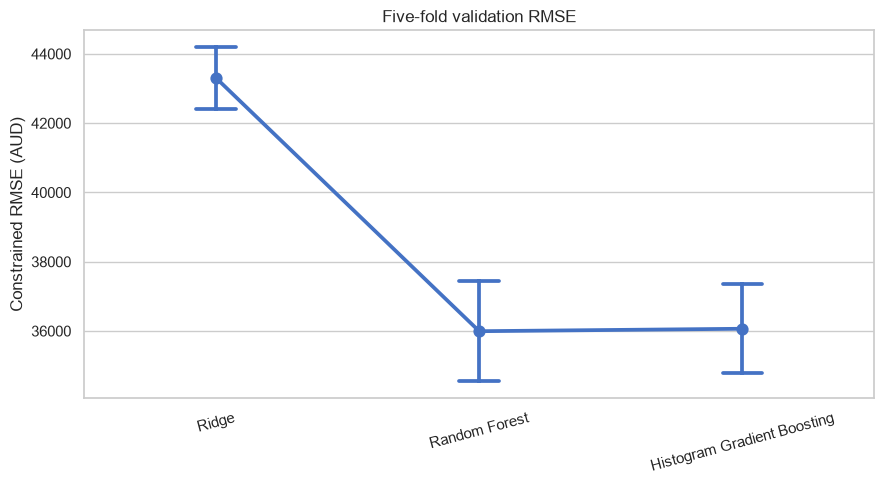

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.pointplot(
    data=validation_detail,
    x="model",
    y="constrained_rmse_aud",
    errorbar="sd",
    capsize=0.15,
    color="#4472C4",
    ax=ax,
)
ax.set(title="Five-fold validation RMSE", xlabel="", ylabel="Constrained RMSE (AUD)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### 8.1 Paired fold comparison and alternative metric

RMSE is the competition metric and appropriately penalises large lending errors, but a small number of large loans can dominate it. MAE is reported alongside RMSE because it describes the typical absolute dollar error and is easier to interpret operationally. MAPE is not suitable here because 26.8% of targets are zero.

Because every candidate uses the same folds, fold-level differences are paired. With only five folds these comparisons are descriptive; they should not be presented as precise inferential confidence intervals.

In [23]:
rmse_by_fold = validation_detail.pivot(
    index="fold", columns="model", values="constrained_rmse_aud"
)
ordered_models = validation_summary.index.tolist()
best_name, second_name = ordered_models[:2]
paired_difference = rmse_by_fold[second_name] - rmse_by_fold[best_name]

paired_fold_comparison = pd.Series(
    {
        "best_initial_model": best_name,
        "closest_challenger": second_name,
        "mean_rmse_advantage_of_best_aud": paired_difference.mean(),
        "folds_won_by_best": int((paired_difference > 0).sum()),
        "folds_won_by_challenger": int((paired_difference < 0).sum()),
        "largest_absolute_fold_difference_aud": paired_difference.abs().max(),
    }
)

display(rmse_by_fold.style.format("${:,.0f}"))
paired_fold_comparison

model,Histogram Gradient Boosting,Random Forest,Ridge
fold,,,
1,"$34,498","$34,346","$42,214"
2,"$37,169","$36,773","$44,148"
3,"$37,120","$36,982","$43,652"
4,"$34,868","$34,509","$42,507"
5,"$36,669","$37,362","$44,007"


best_initial_model                                    Random Forest
closest_challenger                      Histogram Gradient Boosting
mean_rmse_advantage_of_best_aud                              70.602
folds_won_by_best                                                 4
folds_won_by_challenger                                           1
largest_absolute_fold_difference_aud                        693.021
dtype: object

## 9. Out-of-fold error diagnosis

The best initial candidate is selected only for diagnosis. It is **not yet declared the final model**. Out-of-fold predictions provide an honest view of where the current approach fails without reusing training predictions.

In [24]:
best_initial_model = validation_summary.index[0]
best_oof = oof_predictions[best_initial_model]

diagnostics = train[[
    "requested_amount_aud",
    "risk_review_flag",
    "credit_rating",
]].copy()
diagnostics["sanction_rate"] = sanction_rate
diagnostics["actual"] = y
diagnostics["prediction"] = best_oof
diagnostics["residual"] = diagnostics["actual"] - diagnostics["prediction"]
diagnostics["absolute_error"] = diagnostics["residual"].abs()
diagnostics["request_size_band"] = pd.qcut(
    diagnostics["requested_amount_aud"],
    q=5,
    duplicates="drop",
)

error_by_tier = (
    diagnostics.groupby("sanction_rate", observed=True)
    .apply(
        lambda group: pd.Series(
            {
                "n": len(group),
                "rmse_aud": rmse(group["actual"], group["prediction"]),
                "mean_error_aud": group["residual"].mean(),
            }
        ),
        include_groups=False,
    )
)

error_by_request_band = (
    diagnostics.groupby("request_size_band", observed=True)
    .apply(
        lambda group: pd.Series(
            {
                "n": len(group),
                "rmse_aud": rmse(group["actual"], group["prediction"]),
                "mean_absolute_error_aud": group["absolute_error"].mean(),
            }
        ),
        include_groups=False,
    )
)

print("Best initial candidate:", best_initial_model)
display(error_by_tier.style.format({"rmse_aud": "${:,.0f}", "mean_error_aud": "${:,.0f}"}))
display(error_by_request_band.style.format({"rmse_aud": "${:,.0f}", "mean_absolute_error_aud": "${:,.0f}"}))

Best initial candidate: Random Forest


,n,rmse_aud,mean_error_aud
sanction_rate,,,
0.000000,5177.000000,"$60,841","$-30,802"
0.650000,3257.000000,"$11,404","$6,673"
0.700000,5686.000000,"$16,258","$10,671"
0.750000,2568.000000,"$19,962","$14,114"
0.800000,2502.000000,"$29,563","$22,082"
0.850000,42.000000,"$83,623","$39,903"
0.900000,50.000000,"$69,049","$49,066"
1.000000,40.000000,"$76,421","$63,106"


,n,rmse_aud,mean_absolute_error_aud
request_size_band,,,
"(9467.479, 58154.086]",3865.000000,"$9,375","$5,535"
"(58154.086, 97642.096]",3864.000000,"$16,292","$9,666"
"(97642.096, 139523.094]",3864.000000,"$25,214","$15,139"
"(139523.094, 204700.392]",3864.000000,"$37,960","$23,279"
"(204700.392, 933695.43]",3865.000000,"$63,686","$36,322"


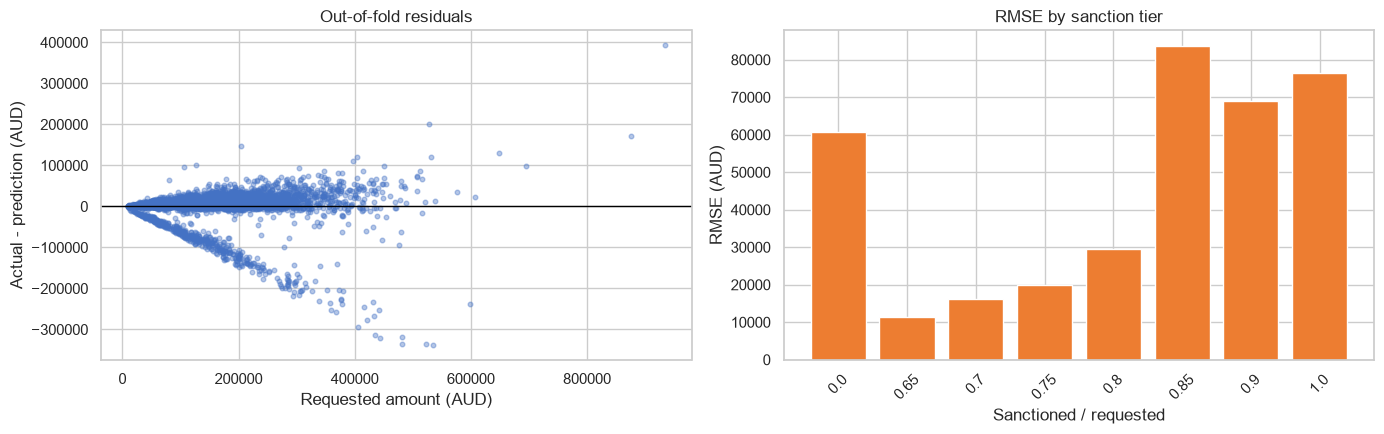

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sample_index = train.sample(n=min(5_000, len(train)), random_state=RANDOM_STATE).index
axes[0].scatter(
    diagnostics.loc[sample_index, "requested_amount_aud"],
    diagnostics.loc[sample_index, "residual"],
    s=11,
    alpha=0.4,
    color="#4472C4",
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title="Out-of-fold residuals", xlabel="Requested amount (AUD)", ylabel="Actual - prediction (AUD)")

plot_error_by_tier = error_by_tier.reset_index()
axes[1].bar(
    plot_error_by_tier["sanction_rate"].astype(str),
    plot_error_by_tier["rmse_aud"],
    color="#ED7D31",
)
axes[1].set(title="RMSE by sanction tier", xlabel="Sanctioned / requested", ylabel="RMSE (AUD)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 10. Feature-engineering ablation

This controlled comparison isolates the contribution of three decisions while holding the model family, hyperparameters, clipping rule, and validation folds fixed. The purpose is to document measured effects, including changes that do not improve the score.

In [26]:
def make_hgb_pipeline(feature_frame):
    categorical = feature_frame.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()
    numeric = [column for column in feature_frame.columns if column not in categorical]
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", SimpleImputer(strategy="median"), numeric),
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                max_categories=254,
                            ),
                        ),
                    ]
                ),
                categorical,
            ),
        ]
    )
    categorical_mask = [False] * len(numeric) + [True] * len(categorical)
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=300,
                    learning_rate=0.06,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    categorical_features=categorical_mask,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


ablation_configurations = {
    "Cleaned raw features": {
        "use_income_backup": False,
        "add_business_features": False,
        "add_missing_indicators": False,
    },
    "+ ratios and missing indicators": {
        "use_income_backup": False,
        "add_business_features": True,
        "add_missing_indicators": True,
    },
    "+ property-age income backup": {
        "use_income_backup": True,
        "add_business_features": True,
        "add_missing_indicators": True,
    },
}

ablation_rows = []
raw_predictors = train.drop(columns=TARGET)
for configuration_name, options in ablation_configurations.items():
    ablation_x = engineer_features(raw_predictors, **options)
    ablation_model = make_hgb_pipeline(ablation_x)

    for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
        fitted_model = clone(ablation_model)
        fitted_model.fit(ablation_x.iloc[train_index], y.iloc[train_index])
        prediction = np.clip(
            fitted_model.predict(ablation_x.iloc[valid_index]),
            0,
            requested_array[valid_index],
        )
        ablation_rows.append(
            {
                "configuration": configuration_name,
                "fold": fold_number,
                "rmse_aud": rmse(y.iloc[valid_index], prediction),
                "mae_aud": mean_absolute_error(y.iloc[valid_index], prediction),
                "feature_count": ablation_x.shape[1],
            }
        )

ablation_detail = pd.DataFrame(ablation_rows)
ablation_summary = (
    ablation_detail.groupby("configuration")
    .agg(
        feature_count=("feature_count", "first"),
        mean_rmse_aud=("rmse_aud", "mean"),
        sd_rmse_aud=("rmse_aud", "std"),
        mean_mae_aud=("mae_aud", "mean"),
    )
    .sort_values("mean_rmse_aud")
)

baseline_ablation_rmse = ablation_summary.loc["Cleaned raw features", "mean_rmse_aud"]
ablation_summary["rmse_change_vs_cleaned_raw_aud"] = (
    ablation_summary["mean_rmse_aud"] - baseline_ablation_rmse
)

ablation_summary.style.format(
    {
        "mean_rmse_aud": "${:,.0f}",
        "sd_rmse_aud": "${:,.0f}",
        "mean_mae_aud": "${:,.0f}",
        "rmse_change_vs_cleaned_raw_aud": "${:+,.0f}",
    }
)

,feature_count,mean_rmse_aud,sd_rmse_aud,mean_mae_aud,rmse_change_vs_cleaned_raw_aud
configuration,,,,,
+ ratios and missing indicators,50,"$36,065","$1,283","$19,047",$-46
+ property-age income backup,50,"$36,074","$1,319","$18,979",$-37
Cleaned raw features,31,"$36,111","$1,185","$19,087",$+0


## 11. Next experiments before choosing the final model

The next iteration should remain driven by the same five folds:

1. **Model the tiered target explicitly.** Compare direct AUD regression with sanction-rate regression and a probability-weighted tier model. Evaluate all predictions in AUD with RMSE.
2. **Tune only promising families.** Use a bounded random search for the strongest tree model instead of an exhaustive grid.
3. **Investigate high-cardinality identifiers.** Compare excluding `property_ref`, treating it as categorical, and a leakage-safe encoding fitted within each fold.
4. **Produce statistical evidence.** Use repeated permutation importance or bootstrap confidence intervals, Ridge coefficient uncertainty, and paired fold-level error differences. Do not rely on one feature-importance chart.
5. **Assess limitations.** Report error by requested-amount band, zero versus positive sanctions, target tier, missingness pattern, and time period.
6. **Only then retrain and submit.** Fit the selected pipeline on all 19,322 labelled rows, predict the 10,000 test rows, validate the exact two-column format, and save a new submission file without overwriting earlier experiments.

## 12. Evidence table for the report

This final table gathers the core numeric evidence produced above. It is a drafting aid: the report should explain each finding, decision, and measured effect rather than paste the table without interpretation.

In [27]:
best_ablation_name = ablation_summary.index[0]

report_evidence = pd.DataFrame(
    [
        {
            "topic": "Target zeros",
            "finding": f"{int((y == 0).sum()):,} rows ({100 * (y == 0).mean():.2f}%)",
            "decision_or_implication": "Stratify folds by sanction tier; avoid MAPE.",
        },
        {
            "topic": "Encoded missing values",
            "finding": f"{int(sentinel_counts['training_minus_999'].sum()):,} training values equal -999",
            "decision_or_implication": "Convert to NaN before learned imputation.",
        },
        {
            "topic": "Corrupted property age",
            "finding": f"{int(exact_matches.sum()):,}/{len(income_property_overlap):,} overlaps equal annual income",
            "decision_or_implication": "Drop entirely; the tested income backup did not improve validation RMSE.",
        },
        {
            "topic": "Best initial model",
            "finding": f"{best_initial_model}: RMSE ${validation_summary.loc[best_initial_model, 'mean_constrained_rmse_aud']:,.0f}",
            "decision_or_implication": "Use as the current benchmark, not the final model.",
        },
        {
            "topic": "Best tested feature configuration",
            "finding": f"{best_ablation_name}: RMSE ${ablation_summary.loc[best_ablation_name, 'mean_rmse_aud']:,.0f}",
            "decision_or_implication": "Retain only transformations supported by validation.",
        },
    ]
)
report_evidence

,topic,finding,decision_or_implication
0,Target zeros,"5,177 rows (26.79%)",Stratify folds by sanction tier; avoid MAPE.
1,Encoded missing values,406 training values equal -999,Convert to NaN before learned imputation.
2,Corrupted property age,"11,524/11,524 overlaps equal annual income",Drop entirely; the tested income backup did no...
3,Best initial model,"Random Forest: RMSE $35,994","Use as the current benchmark, not the final mo..."
4,Best tested feature configuration,"+ ratios and missing indicators: RMSE $36,065",Retain only transformations supported by valid...


## 13. Reproducibility record

Record these versions in the final README, together with the command used to run the notebook or script.

In [28]:
versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "Platform": platform.platform(),
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "random_seed": RANDOM_STATE,
    }
)
versions

Python                                       3.13.9
Platform        macOS-26.6.2-arm64-arm-64bit-Mach-O
NumPy                                         2.3.5
pandas                                        2.3.3
scikit-learn                                  1.9.0
random_seed                                      42
dtype: object